Figura guardada en: gravity_style_demo.pdf


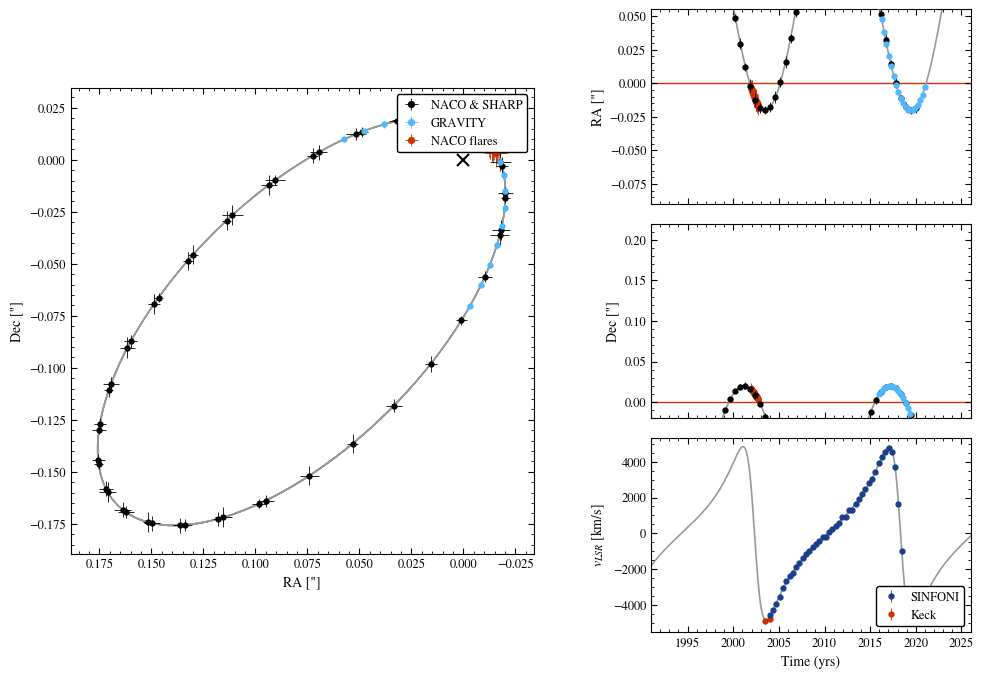

In [2]:
"""
Template para replicar el estilo de figuras de la colaboración GRAVITY (ESO/MPE)
como en Gillessen et al. / GRAVITY Collaboration (órbita de S2 alrededor de Sgr A*)

Uso:
    python gravity_style_template.py
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# 1.  CONFIGURACIÓN GLOBAL DE ESTILO
# ─────────────────────────────────────────────
def apply_gravity_style():
    """Aplica los rcParams que imitan el estilo GRAVITY."""
    mpl.rcParams.update({
        # --- Fuente (Computer Modern / STIX como en LaTeX) ---
        "font.family":        "serif",
        "font.serif":         ["STIXGeneral", "CMU Serif", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset":   "stix",
        "font.size":          10,
        "axes.titlesize":     10,
        "axes.labelsize":     10,
        "xtick.labelsize":    9,
        "ytick.labelsize":    9,
        "legend.fontsize":    9,

        # --- Ticks hacia adentro en los 4 lados ---
        "xtick.direction":    "in",
        "ytick.direction":    "in",
        "xtick.top":          True,
        "ytick.right":        True,
        "xtick.major.size":   4,
        "ytick.major.size":   4,
        "xtick.minor.size":   2,
        "ytick.minor.size":   2,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,

        # --- Líneas y marcadores ---
        "lines.linewidth":    1.2,
        "lines.markersize":   4,
        "errorbar.capsize":   0,        # sin caps en barras de error

        # --- Ejes y marco ---
        "axes.linewidth":     0.8,
        "axes.edgecolor":     "black",
        "axes.facecolor":     "white",
        "figure.facecolor":   "white",

        # --- Leyenda ---
        "legend.frameon":     True,
        "legend.framealpha":  1.0,
        "legend.edgecolor":   "black",
        "legend.handlelength": 1.5,

        # --- Guardado ---
        "savefig.dpi":        200,
        "savefig.bbox":       "tight",
    })

# ─────────────────────────────────────────────
# 2.  PALETA DE COLORES GRAVITY
# ─────────────────────────────────────────────
C = {
    "naco":    "black",          # NACO & SHARP  (astrometría principal)
    "gravity": "#4DB8FF",        # GRAVITY       (azul cian)
    "flares":  "#CC3300",        # NACO flares / Keck  (rojo-naranja)
    "sinfoni": "#1A3E8C",        # SINFONI       (azul oscuro)
    "fit":     "#999999",        # curva de ajuste (gris)
    "refline": "#CC3300",        # línea horizontal de referencia
}

MARKER_KW = dict(fmt="o", markersize=3.5, capsize=0, linewidth=0.6)

# ─────────────────────────────────────────────
# 3.  DATOS SINTÉTICOS (reemplace con los suyos)
# ─────────────────────────────────────────────
rng = np.random.default_rng(42)

# Parámetros orbitales simplificados para S2
T  = 16.0          # período en años
t0 = 2002.33       # periastro

def orbit_xy(t):
    """Posición 2D sintética (elipse proyectada) para demostración."""
    phase = 2 * np.pi * (t - t0) / T
    a, b  = 0.125, 0.060
    e     = 0.88
    # órbita elíptica simple (no Kepleriana exacta, solo ilustrativa)
    x = a * (np.cos(phase) - e)
    y = b * np.sin(phase)
    # rotación ~135°
    ang = np.radians(135)
    xr  =  x * np.cos(ang) - y * np.sin(ang)
    yr  =  x * np.sin(ang) + y * np.cos(ang)
    return xr, yr

def radial_velocity(t):
    phase = 2 * np.pi * (t - t0) / T
    return -2300 * np.sin(phase) / (1 - 0.88 * np.cos(phase))

# ---- Tiempos ----
t_naco    = np.linspace(1992, 2020, 52)
t_gravity = np.linspace(2016, 2021, 20)
t_flares  = t0 + rng.uniform(-0.4, 0.4, 35)
t_rv_sinfoni = np.linspace(2004, 2021, 48)
t_rv_keck    = np.array([2003.5, 2004.0])
t_fit     = np.linspace(1990, 2026, 400)

# ---- Posiciones ----
xn, yn = orbit_xy(t_naco)
xg, yg = orbit_xy(t_gravity)
xf, yf = orbit_xy(t_flares)
xfit, yfit = orbit_xy(t_fit)

# ---- Velocidades radiales ----
rv_sinfoni = radial_velocity(t_rv_sinfoni) + rng.normal(0, 80, len(t_rv_sinfoni))
rv_keck    = radial_velocity(t_rv_keck)    + rng.normal(0, 120, 2)

# ─────────────────────────────────────────────
# 4.  FIGURA PRINCIPAL
# ─────────────────────────────────────────────
apply_gravity_style()

fig = plt.figure(figsize=(10, 7))

# GridSpec: columna izquierda ancha + 3 paneles derechos
gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    left=0.07, right=0.97,
    bottom=0.08, top=0.97,
    wspace=0.30, hspace=0.10,
    width_ratios=[1.45, 1],
    height_ratios=[1, 1, 1],
)

ax_orb = fig.add_subplot(gs[:, 0])   # panel orbital (ocupa las 3 filas)
ax_ra  = fig.add_subplot(gs[0, 1])
ax_dec = fig.add_subplot(gs[1, 1])
ax_rv  = fig.add_subplot(gs[2, 1])

# ── 4a. Panel orbital ──────────────────────────────────────────────────────
ax_orb.plot(xfit, yfit, "-", color=C["fit"], lw=1.2, zorder=1)

ax_orb.errorbar(xn, yn,
                xerr=rng.uniform(2e-3, 5e-3, len(xn)),
                yerr=rng.uniform(2e-3, 5e-3, len(xn)),
                color=C["naco"], ecolor=C["naco"],
                label="NACO & SHARP", zorder=3, **MARKER_KW)

ax_orb.errorbar(xg, yg,
                xerr=rng.uniform(5e-4, 2e-3, len(xg)),
                yerr=rng.uniform(5e-4, 2e-3, len(xg)),
                color=C["gravity"], ecolor=C["gravity"],
                label="GRAVITY", zorder=4, **MARKER_KW)

ax_orb.errorbar(xf, yf,
                xerr=rng.uniform(3e-3, 8e-3, len(xf)),
                yerr=rng.uniform(3e-3, 8e-3, len(xf)),
                color=C["flares"], ecolor=C["flares"],
                label="NACO flares", zorder=2, **MARKER_KW)

# Sgr A* en el origen
ax_orb.plot(0, 0, "x", color="black", markersize=8, mew=1.5, zorder=5)

ax_orb.set_xlabel('RA ["]')
ax_orb.set_ylabel('Dec ["]')
ax_orb.invert_xaxis()   # RA crece hacia la izquierda (convención astronómica)
ax_orb.set_aspect("equal")
ax_orb.legend(loc="upper right", markerscale=1.2)

# ── 4b–c. RA(t) y Dec(t) ──────────────────────────────────────────────────
for ax, data_n, data_g, data_f, ylabel, ylims in [
    (ax_ra,  xn, xg, xf, 'RA ["]',  (-0.09, 0.055)),
    (ax_dec, yn, yg, yf, 'Dec ["]', (-0.02, 0.22 )),
]:
    # línea de referencia horizontal (flares ≈ 0)
    ax.axhline(0, color=C["refline"], lw=1.0, zorder=1)

    # curva de ajuste
    ax.plot(t_fit, orbit_xy(t_fit)[0 if ylabel.startswith("R") else 1],
            "-", color=C["fit"], lw=1.2, zorder=2)

    ax.errorbar(t_naco, data_n,
                yerr=rng.uniform(2e-3, 5e-3, len(t_naco)),
                color=C["naco"], ecolor=C["naco"], zorder=4, **MARKER_KW)
    ax.errorbar(t_gravity, data_g,
                yerr=rng.uniform(5e-4, 2e-3, len(t_gravity)),
                color=C["gravity"], ecolor=C["gravity"], zorder=5, **MARKER_KW)
    ax.errorbar(t_flares, data_f,
                yerr=rng.uniform(3e-3, 8e-3, len(t_flares)),
                color=C["flares"], ecolor=C["flares"], zorder=3, **MARKER_KW)

    ax.set_ylabel(ylabel)
    ax.set_xlim(1991, 2026)
    ax.set_ylim(*ylims)

# Ocultar etiquetas x en paneles superiores
ax_ra.set_xticklabels([])
ax_dec.set_xticklabels([])

# ── 4d. Velocidad radial ───────────────────────────────────────────────────
ax_rv.plot(t_fit, radial_velocity(t_fit), "-", color=C["fit"], lw=1.2, zorder=1)

ax_rv.errorbar(t_rv_sinfoni, rv_sinfoni,
               yerr=rng.uniform(50, 150, len(t_rv_sinfoni)),
               color=C["sinfoni"], ecolor=C["sinfoni"],
               label="SINFONI", zorder=4, **MARKER_KW)
ax_rv.errorbar(t_rv_keck, rv_keck,
               yerr=rng.uniform(100, 200, 2),
               color=C["flares"], ecolor=C["flares"],
               label="Keck", zorder=3, **MARKER_KW)

ax_rv.set_xlabel("Time (yrs)")
ax_rv.set_ylabel(r"$v_{LSR}$ [km/s]")
ax_rv.set_xlim(1991, 2026)
ax_rv.legend(loc="lower right")

# ── Ajuste fino de ticks x compartidos ────────────────────────────────────
for ax in (ax_ra, ax_dec, ax_rv):
    ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2020, 2025])

ax_rv.set_xticklabels(["1995", "2000", "2005", "2010", "2015", "2020", "2025"])

# ─────────────────────────────────────────────
# 5.  GUARDAR
# ─────────────────────────────────────────────
out = "gravity_style_demo.pdf" 
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Figura guardada en: {out}")
plt.show()